In [2]:
import app
import os
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import box
import rasterio
import rasterio.plot as rplt
import rasterio.windows  as rw
from rasterio.transform import Affine
from matplotlib_scalebar.scalebar import ScaleBar
import numpy as np
import cmocean as cmo

app.setup_logger(use_console_handler=False, use_file_handler=True)

import logging
logger = logging.getLogger(__name__)
logger.setLevel("INFO")

In [3]:
base_directory = r"D:\PhD\21_Experiments\TidesDamageDriver"
drainages_folder = os.path.join(
    base_directory, "03_cleaned", "drainages"
)
drainages_ref_folder = os.path.join(
    base_directory, "02_processed", "02_drainages"
)
img_folder = os.path.join(
    base_directory, "01_raw", "L8S2S1-events"
)
figure_folder = os.path.join(
    base_directory, "figures"
)

In [4]:
gdf = app.lakes.plotting.get_geodataframes(drainages_folder)[0]
gdf_ref = app.lakes.plotting.get_geodataframes(drainages_ref_folder, ["_e."])[0]
gdf

,label,index,year,lon,lat,start_date,end_date,mean-0,median-0,area-0,volume-0,mean-1,median-1,volume-1,dmg,act,lai,fuerst,fuerst+lai,geometry
0,A,29,2019,95.688019,-66.671201,2019-12-24,2019-12-31,1.130955,1.104492,66600.0,75321.609664,0.000000,0.000000,0.000000,0.235667,0.269375,NaN,NaN,NaN,"POLYGON ((95.6809 -66.67233, 95.68083 -66.6720..."
1,B,28,2019,95.737264,-66.660983,2019-12-22,2019-12-31,1.283588,1.089844,55800.0,71624.206638,0.313599,0.335693,1411.193848,0.333090,0.458099,1.0,0.0,1.0,"POLYGON ((95.73322 -66.6612, 95.73302 -66.6604..."
2,C,39,2019,95.759349,-66.646830,2020-01-07,2020-01-13,0.569657,NaN,NaN,64086.362457,0.307686,NaN,6092.188454,0.333090,0.458099,1.0,0.0,1.0,"POLYGON ((95.75933 -66.64674, 95.75935 -66.646..."
3,D,8,2016,96.040652,-66.571884,2017-01-27,2017-02-03,1.441006,1.357422,90900.0,130987.440419,0.222290,0.222290,600.183105,0.356259,0.574090,1.0,0.0,1.0,"POLYGON ((96.03223 -66.57217, 96.03216 -66.571..."
4,E,32,2019,97.782530,-66.594982,2020-01-30,2020-02-03,2.299795,2.486328,154800.0,356008.215523,0.631179,0.626221,14769.579649,0.139619,0.533078,1.0,0.0,1.0,"POLYGON ((97.7797 -66.5975, 97.77961 -66.59723..."
5,F,40,2019,98.104002,-66.492315,2020-01-30,2020-02-03,1.125474,NaN,NaN,109621.166992,0.495280,NaN,5646.196747,0.169961,0.513592,1.0,1.0,2.0,"POLYGON ((98.10397 -66.49223, 98.10399 -66.492..."
6,G,41,2019,98.493578,-65.782618,2020-01-04,2020-01-11,0.583205,NaN,NaN,30501.635742,NaN,NaN,0.000000,0.430535,0.801361,1.0,0.0,1.0,"POLYGON ((98.49355 -65.78253, 98.49357 -65.782..."
7,H,17,2018,98.847890,-66.359584,2019-01-31,2019-02-08,0.914807,0.891113,99900.0,91389.173824,0.595006,0.585693,7497.070205,0.284860,0.313371,0.0,0.0,0.0,"POLYGON ((98.84161 -66.36032, 98.84131 -66.359..."
8,I,26,2019,98.870325,-66.357777,2020-01-20,2020-01-27,0.860971,0.859863,93600.0,80586.860847,0.818970,0.876709,7370.727539,0.256579,0.386947,0.0,0.0,0.0,"POLYGON ((98.86448 -66.35728, 98.86428 -66.356..."
9,J,23,2019,99.719303,-66.264245,2020-01-04,2020-01-11,0.992884,1.030273,59400.0,58977.294266,0.483887,0.489014,2612.988281,0.135486,0.681241,0.0,0.0,0.0,"POLYGON ((99.71542 -66.26532, 99.71531 -66.265..."


In [5]:
chosen_files ={
    2: {
        "files":["2_026_2_20170131T021551_20170131T021548_T47DNG.tif", "2_027_1_LC08_112106_20170203.tif"],
        "satellite": ["S2", "L8"]
    },
    24: {
        "files": ["24_023_1_LC08_113107_20200118.tif", "24_027_1_LC08_112107_20200127.tif"],
        "satellite": ["L8", "L8"]
    }
}

In [6]:
total_width = 18 / 2.54

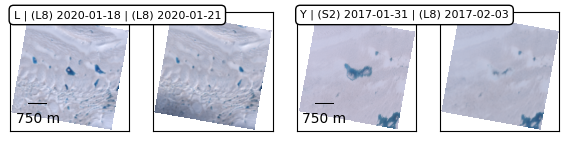

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(total_width, 4 / 2.54))
for i_n, n in enumerate([24, 2]):
    gdf_n = gdf.loc[gdf["index"] == n].iloc[0]
    gdf_n_ref = gdf_ref.iloc[0]

    for ax in axes.ravel():
        ax.set_facecolor('white')
        ax.tick_params(
            axis="both",  # changes apply to the x-axis
            which="both",  # both major and minor ticks are affected
            bottom=False,  # ticks along the bottom edge are off
            top=False,  # ticks along the top edge are off
            left=False,
            right=False,
            labelbottom=False,
            labelleft=False,
        )

    ax = axes.ravel()[2*i_n]
    
    with rasterio.open(os.path.join(img_folder, str(n), chosen_files[n]["files"][0])) as src:
        if chosen_files[n]["satellite"][0] == "S2":
            raster, meta = app.lakes.tiffiles.reproject_in_memory(src, "EPSG:3031")
            raster = raster[:3]
            raster[:, raster.sum(axis=0) == 0] = np.nan  # Set nodata to NaN for better visualization
            transform = meta['transform']
        else:
            raster = src.read()
            raster = raster[:3]
            meta = src.meta
            transform = src.transform
    raster = raster[::-1, :, :]
    rplt.show(raster, ax=ax, transform=transform, zorder = 1)
    
    scalebar = ScaleBar(
        dx=1,                   # scale factor: 1 data unit = 1 meter
        units='m',              # display unit
        location='lower left',  # scalebar position
        length_fraction=0.2,    # bar is 20% of axis width
        scale_loc='bottom',     # label below the bar
        box_alpha=0,            # no background box
        color='black',          # scalebar color
        frameon=False,          # no frame around scalebar
        font_properties={'size': 10},  # label font size
        border_pad=0.2          # minimal padding
    )  # 1 data unit = 1 meter
    ax.add_artist(scalebar)
    
    ax = axes.ravel()[2*i_n + 1]
    ax.text(-1.17, 1.02, f"{gdf_n['label']} | ({chosen_files[n]['satellite'][0]}) {gdf_n['start_date']} | ({chosen_files[n]['satellite'][1]}) {gdf_n['end_date']}",
            transform=ax.transAxes, zorder = 10, fontsize=8, ha='left', va='top', bbox=dict(facecolor='white', alpha=1, edgecolor='black', boxstyle='round,pad=0.4'))
    with rasterio.open(os.path.join(img_folder, str(n), chosen_files[n]["files"][1])) as src:
        if chosen_files[n]["satellite"][1] == "S2":
            raster, meta = app.lakes.tiffiles.reproject_in_memory(src, "EPSG:3031")
            transform = meta['transform']
        else:
            raster = src.read()
            meta = src.meta
            transform = src.transform
    raster = raster[:3][::-1, :, :]
    rplt.show(raster, ax=ax, transform=transform, zorder = 1)

fig.savefig(os.path.join(figure_folder, "figure_01b.pdf"), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(figure_folder, "figure_01b.png"), dpi=300, bbox_inches='tight')